1. Start with HMGCR as the seed protein.
2. Query STRING for interaction partners.
3. Represent each protein as a node.
4. Represent each interaction as a weighted edge.
5. Compute how far each protein is from HMGCR.
6. Keep only the 1-hop or 2-hop neighborhood.
7. Save the graph plus node/edge tables for later annotation and modeling.

In [1]:
import time
import requests
import csv

BASE_URL = "https://string-db.org/api"
OUTPUT_FORMAT = "json"
SPECIES = 9606  # human
CALLER_IDENTITY = "hmgcr_vscode_demo"

def map_identifier(gene_name: str, species: int = SPECIES):
    """
    Map a gene/protein name like HMGCR to a STRING identifier.
    """
    url = f"{BASE_URL}/{OUTPUT_FORMAT}/get_string_ids"
    data = {
        "identifiers": gene_name,
        "species": species,
        "caller_identity": CALLER_IDENTITY,
    }

    r = requests.post(url, data=data, timeout=30)
    r.raise_for_status()
    results = r.json()

    if not results:
        raise ValueError(f"No STRING ID found for {gene_name}")

    return results[0]  # best match

def get_interaction_partners(string_id: str, species: int = SPECIES, limit: int = 25, required_score: int = 700):
    """
    Pull STRING interaction partners for one protein.
    required_score:
      400 = medium confidence
      700 = high confidence
      900 = highest confidence
    """
    url = f"{BASE_URL}/{OUTPUT_FORMAT}/interaction_partners"
    data = {
        "identifiers": string_id,
        "species": species,
        "limit": limit,
        "required_score": required_score,
        "caller_identity": CALLER_IDENTITY,
    }

    r = requests.post(url, data=data, timeout=30)
    r.raise_for_status()
    return r.json()

def save_partners_to_csv(rows, filename="hmgcr_partners.csv"):
    if not rows:
        print("No rows to save.")
        return

    fieldnames = sorted({k for row in rows for k in row.keys()})

    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved {len(rows)} rows to {filename}")



In [2]:
gene = "HMGCR"

print(f"Mapping {gene}...")
mapped = map_identifier(gene)
print("Best match:")
print(mapped)

# STRING asks users to wait about one second between calls
time.sleep(1)

string_id = mapped["stringId"]

print(f"\nFetching interaction partners for {gene} ({string_id})...")
partners = get_interaction_partners(
    string_id=string_id,
    limit=30,
    required_score=700
)

print(f"Retrieved {len(partners)} partners\n")

for row in partners[:10]:
    preferred_a = row.get("preferredName_A")
    preferred_b = row.get("preferredName_B")
    score = row.get("score")
    print(f"{preferred_a} -- {preferred_b} | score={score}")

#save_partners_to_csv(partners)

Mapping HMGCR...
Best match:
{'queryIndex': 0, 'queryItem': 'HMGCR', 'stringId': '9606.ENSP00000287936', 'ncbiTaxonId': 9606, 'taxonName': 'Homo sapiens', 'preferredName': 'HMGCR', 'annotation': '3-hydroxy-3-methylglutaryl-coenzyme A reductase; Transmembrane glycoprotein that is the rate-limiting enzyme in cholesterol biosynthesis as well as in the biosynthesis of nonsterol isoprenoids that are essential for normal cell function including ubiquinone and geranylgeranyl proteins.'}

Fetching interaction partners for HMGCR (9606.ENSP00000287936)...
Retrieved 30 partners

HMGCR -- INSIG1 | score=0.999
HMGCR -- MVK | score=0.999
HMGCR -- HMGCS1 | score=0.999
HMGCR -- HMGCS2 | score=0.999
HMGCR -- INSIG2 | score=0.99
HMGCR -- SREBF2 | score=0.985
HMGCR -- SQLE | score=0.973
HMGCR -- FDPS | score=0.967
HMGCR -- SREBF1 | score=0.956
HMGCR -- FDFT1 | score=0.954


In [4]:
edges = []
for row in partners:
    edges.append({
        "source": row.get("preferredName_A"),
        "target": row.get("preferredName_B"),
        "score": row.get("score"),
    })

edges

[{'source': 'HMGCR', 'target': 'INSIG1', 'score': 0.999},
 {'source': 'HMGCR', 'target': 'MVK', 'score': 0.999},
 {'source': 'HMGCR', 'target': 'HMGCS1', 'score': 0.999},
 {'source': 'HMGCR', 'target': 'HMGCS2', 'score': 0.999},
 {'source': 'HMGCR', 'target': 'INSIG2', 'score': 0.99},
 {'source': 'HMGCR', 'target': 'SREBF2', 'score': 0.985},
 {'source': 'HMGCR', 'target': 'SQLE', 'score': 0.973},
 {'source': 'HMGCR', 'target': 'FDPS', 'score': 0.967},
 {'source': 'HMGCR', 'target': 'SREBF1', 'score': 0.956},
 {'source': 'HMGCR', 'target': 'FDFT1', 'score': 0.954},
 {'source': 'HMGCR', 'target': 'AMFR', 'score': 0.953},
 {'source': 'HMGCR', 'target': 'CYP51A1', 'score': 0.948},
 {'source': 'HMGCR', 'target': 'UBIAD1', 'score': 0.945},
 {'source': 'HMGCR', 'target': 'PRKAA1', 'score': 0.938},
 {'source': 'HMGCR', 'target': 'PRKAG1', 'score': 0.932},
 {'source': 'HMGCR', 'target': 'PRKAG2', 'score': 0.932},
 {'source': 'HMGCR', 'target': 'PRKAA2', 'score': 0.932},
 {'source': 'HMGCR', 'ta

In [5]:
import pandas as pd

edges_df = pd.DataFrame(edges)

In [6]:
edges_df

,source,target,score
0,HMGCR,INSIG1,0.999
1,HMGCR,MVK,0.999
2,HMGCR,HMGCS1,0.999
3,HMGCR,HMGCS2,0.999
4,HMGCR,INSIG2,0.990
5,HMGCR,SREBF2,0.985
6,HMGCR,SQLE,0.973
7,HMGCR,FDPS,0.967
8,HMGCR,SREBF1,0.956
9,HMGCR,FDFT1,0.954


In [7]:
import networkx as nx

G = nx.from_pandas_edgelist(
    edges_df,
    source="source",
    target="target",
    edge_attr="score",
    create_using=nx.Graph()
)

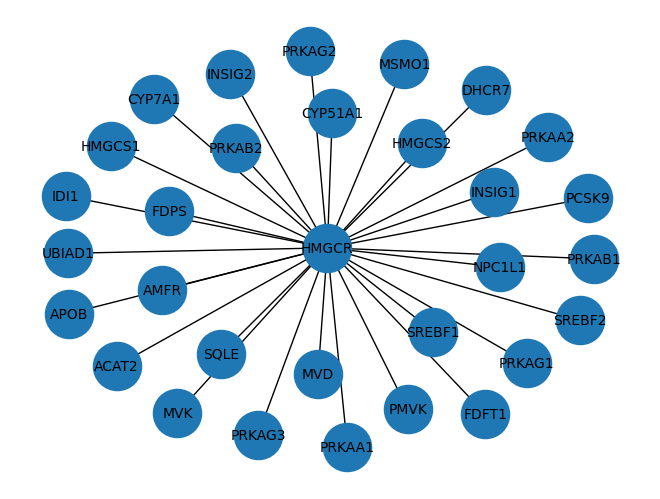

In [8]:
import matplotlib.pyplot as plt

# Draw the graph
pos = nx.spring_layout(G, seed=42)  # positions nodes nicely

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=10
)

plt.show()